### 静态分支（Static Branch）

节点的下游候选节点 **在图编译阶段就完全确定**，只是运行时根据条件选择哪条边执行。

- 特点：
  - 下游节点集合固定，数量、目标在编译时确定
  - 运行时可选择**一个或多个**下游目标
  - 可以用来做条件分支，但不生成新的节点

⚡ 核心判断：

> **编译期知道下游集合 → 静态分支**

#### 并行节点

{'topic': '猫咪', 'poem': '为您创作了一首关于猫咪的七言绝句，格律严谨（平水韵七阳），意境生动可爱：\n\n**《春日戏猫》**\n\n**娇慵向日影初长，**\n**玉爪轻翻扑蝶忙。**\n**忽见游蜂惊跃起，**\n**梅花落处满庭芳。**\n\n**【意境赏析】**\n* **第一句**写“静”：描绘了猫咪（狸奴）在温暖的阳光下慵懒打盹的娇憨模样，日影渐渐拉长，透着岁月静好的悠闲。\n* **第二句**写“动”：猫咪玩心忽起，用雪白如玉的小爪子轻轻翻扑着飞舞的蝴蝶，动作灵动活泼。\n* **第三句**写“转折”：正扑着蝴蝶，忽然又瞧见一只飞过的蜜蜂，立刻被吸引了注意力，警觉又兴奋地惊跳起来。\n* **第四句**写“余韵”：猫咪在院子里欢快地跑过，地上留下一串串宛如梅花般的可爱脚印，仿佛它把春天的芬芳与生机洒满了整个庭院（“满庭芳”既是词牌名，也暗指满院芬芳，表达对猫咪的喜爱之情）。 \n\n*(注：诗中“日、玉、扑、蝶、忽、跃、落”在古汉语平水韵中均为入声字，归为仄声，完全符合七绝“平起首句入韵”的严格格律。)*', 'joke': '这里有两个关于猫咪的笑话，希望能博你一笑：\n\n**笑话一：面试**\n\n一只猫咪去参加“家庭主宰”职位的面试。\n面试官（人类）问：“请问你有什么特长？”\n猫咪舔了舔爪子说：“我会在你居家办公时，精准地躺在你的键盘上，并帮你发送一堆乱码给你的老板。”\n面试官皱了皱眉：“这算什么特长？还有呢？”\n猫咪接着说：“我还能在你熟睡时，精准地踩你的鼻子，并在凌晨三点为你举办一场‘卧室跑酷重金属演唱会’。”\n面试官有点生气了：“这些听起来都很烦人！你到底有什么核心竞争力？”\n猫咪停下动作，冷冷地盯着面试官，突然发出了一阵甜美的“呼噜呼噜”声，然后顺势倒下翻了个肚皮。\n面试官立刻眼眶泛红，双手奉上钱包：“别说了！我的工资卡给你，猫条管够，明天就搬进来，主子！”\n\n***\n\n**笑话二：科学精神**\n\n主人看着猫咪又一次把桌子上的水杯推到地上摔碎，终于忍不住崩溃大喊：\n“你为什么总是喜欢把桌子上的东西推下去？！你是不是故意的！”\n猫咪优雅地跳下桌子，回头鄙视地看了主人一眼，叹了口气说：\n“愚蠢的人类，我这叫严谨的科学精神。我每天都在测试地球的重力系统是否还在正常运行。毕竟，如果哪天杯子

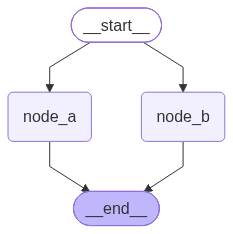

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_qwq import ChatQwen
from langchain.messages import HumanMessage

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatQwen(
    model="qwen3.7-max",
)

class OverAllState(TypedDict):
    topic: str
    poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke(
        [
            HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")
        ]
    ).content
    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke(
        [
            HumanMessage(f"写一个关于 {state['topic']} 的笑话")
        ]
    ).content
    return {
        "joke": joke
    }

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_edge(START, "node_a")
builder.add_edge(START, "node_b")

builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
res = graph.invoke({"topic": "猫咪"})
print(res)

from IPython.display import display

display(graph)

============================== -> poem_res <- ==============================
{'topic': '布偶狗', 'content_type': '诗', 'poem': '为您创作了一首关于“布偶狗”（毛绒玩具狗）的七言绝句。这首诗着重描写了它柔软的外表以及无声陪伴带来的温暖慰藉。\n\n**《咏布偶狗》**\n\n**绒身软耳伴床头，**\n**默守无声解客愁。**\n**莫道棉心无岁月，**\n**长留温暖伴清秋。**\n\n**【诗意赏析】**\n* **第一句**：“绒身软耳”生动勾勒出布偶狗毛茸茸、软乎乎的可爱外形，点明它常伴主人床头的温馨场景。\n* **第二句**：“默守无声”写出了它作为布偶的特性，虽不会像真狗那样叫唤撒娇，却能静静陪伴，化解主人心中的愁绪。\n* **第三句**：“棉心”是巧妙的双关语，既指布偶狗内部的棉花填充物，也比喻它带给人的贴心与柔软；“无岁月”指它没有生命，不会随时间老去。\n* **第四句**：升华情感，表达布偶狗虽为静物，却能长久地传递温度，陪伴主人度过每一个清冷的秋日（泛指漫长岁月）。\n\n*(注：此诗严格遵循平水韵“十一尤”韵部，为七绝平起入韵格律。)*'}
============================== -> joke_res <- ==============================
{'topic': '布偶狗', 'content_type': '笑话', 'joke': '这里给您分享一个关于“布偶狗”（毛绒玩具狗）和真狗的笑话：\n\n小明买了一只极其逼真的“布偶狗”毛绒玩具，随手放在了客厅的沙发上。\n\n他家养了一只精力旺盛的二哈。二哈溜达过来，以为家里来了新成员，立刻热情地凑过去闻了闻，然后疯狂摇尾巴，试图邀请对方一起玩。\n\n但布偶狗当然一动不动。\n\n二哈觉得这只新来的狗太高冷了，于是退后两步，对着它“汪”了一声，意思是：“别装酷了，快起来玩！”\n布偶狗依然保持着微笑，纹丝不动。\n\n二哈急了，觉得自己的尊严受到了挑战。它冲上前，一口咬住了布偶狗的耳朵，用力往下一扯。\n\n只听“嘶啦”一声，布偶狗的耳朵被扯破了，里面白花花的棉花瞬间漏了出来，掉了一地。\n\n二哈瞬间愣住了。它呆呆地看着

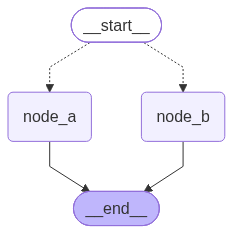

In [12]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_qwq import ChatQwen

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatQwen(
    model="qwen3.7-max",
)


class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def router(state: OverAllState) -> Literal["node_a", "node_b"]:
    if "诗" in state["content_type"]:
        return "node_a"
    return "node_b"

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_conditional_edges(START, router)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶狗", "content_type": "诗"})
joke_res = graph.invoke({"topic": "布偶狗", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)


============================== -> poem_res <- ==============================
{'topic': '布偶狗', 'content_type': '诗', 'poem': '《咏布偶狗》\n身被绒衣性亦温，非生非死亦非真。\n独倚东窗憨可掬，笑他世上弄潮人。\n\n赏析：这首作品以布偶狗为题，通过“绒衣”、“憨可掬”等意象，生动描绘其温顺可爱的形象。后两句“独倚东窗憨可掬，笑他世上弄潮人”，巧妙借物抒怀，以布偶狗的憨态反衬世态纷扰，表达超然物外、淡泊自守的情怀，语言凝练而意蕴深长。'}
============================== -> joke_res <- ==============================
{'topic': '布偶狗', 'content_type': '笑话', 'joke': '“布偶狗”这个梗，通常指的是那种性格极其温顺、怎么摆弄都不反抗，像布偶一样任人摆布的狗狗。最常见的品种就是布偶猫的狗界平替——**金毛**或者**巨贵**。\n\n这里给您写一个：\n\n---\n\n**《论布偶狗的自我修养》**\n\n我养了一只“布偶狗”——一只性格好到离谱的金毛。\n\n今天带它去宠物店洗澡，老板为了省事，直接把它当成了店里的“示范模特”。\n\n老板给一只凶巴巴的泰迪剪毛，泰迪汪汪乱叫。老板灵机一动，把我家金毛抱上操作台，当着泰迪的面，把我家狗又是揉脸又是扯耳朵，最后还拿梳子给它梳了个“冲天辫”。\n\n我家狗全程一脸“我是谁？我在哪？你要干嘛都行”的佛系表情。\n\n泰迪看傻了，当场闭嘴，乖乖配合剪毛。\n\n洗完澡回家，我老婆觉得好玩，又把它翻过来，给它肚皮上贴了个“此面向敌”的贴纸。它依然一动不动，眼神放空，仿佛在说：“人类，你们开心就好。”\n\n那一刻，我明白了——**我养的根本不是狗，是狗界的“安乐公”**。\n\n**最绝的是，晚上我吃宵夜，它明明馋得口水都滴到地板上了，但因为我没发“开饭”指令，它就硬生生保持着“布偶坐”的姿势，一动不动地盯着我。**\n\n我老婆感叹：“别说，这狗拿来当靠枕，比沙发还舒服。”\n\n我默默补了一句：\n\n“你试试跟它吵架，它连回嘴都不会，只会拿舌头舔你火气。这哪是狗啊，这是**我上辈子欠的

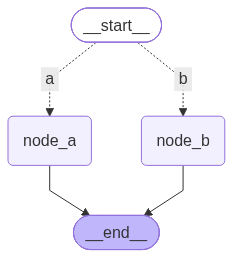

In [ ]:
# 使用path_map

from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_qwq import ChatQwen

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatQwen(
    model="qwen3.7-max",
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def router1(state: OverAllState) -> Literal["a", "b"]:
    if "诗" in state["content_type"]:
        return "a"
    return "b"

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_conditional_edges(
    START,
    router1,
    path_map={
        "a": "node_a",
        "b": "node_b",
    }
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶狗", "content_type": "诗"})
joke_res = graph.invoke({"topic": "布偶狗", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)

============================== -> poem_res <- ==============================
{'topic': '布偶狗', 'content_type': '诗', 'poem': '这是一首为您创作的关于“布偶狗”的七言绝句，既写出了它毛茸茸的可爱外表，也表达了它安静陪伴的温馨情感：\n\n**《咏布偶狗》**\n\n**柔绒软耳伴床头，**\n**不语憨姿解客愁。**\n**何须夜吠惊残梦，**\n**自有温情暖素秋。**\n\n**【平仄格律】**（平水韵·十一尤）\n平平仄仄仄平平，仄仄平平仄仄平。\n平平仄仄平平仄，仄仄平平仄仄平。\n\n**【诗意赏析】**\n* **第一句**：点明了布偶狗的材质与特征，“柔绒”与“软耳”勾勒出它毛茸茸、软乎乎的可爱模样，静静陪伴在主人的床头。\n* **第二句**：写它的神态与作用。虽然它不会说话，但那憨态可掬的样子，足以化解主人心中的烦忧与疲惫。\n* **第三句**：巧妙地与真实的宠物狗作对比。它不会在半夜因为一点动静就吠叫，从而惊扰了主人的好梦。\n* **第四句**：情感升华。它虽然安静无声，却有着独特的陪伴温度，在清冷的秋日里，给主人带来满满的温暖与治愈。', 'ci_poem': '为您创作了两首关于“布偶狗”的词。一首是**古典词牌风格**，用婉约的笔触写它的长情陪伴；另一首是**现代流行歌词风格**，更贴近生活，充满温暖与治愈的回忆。希望您喜欢。\n\n### 第一首：古典词牌风\n**《鹧鸪天·布偶犬》**\n\n绒线缝成小犬身，晶眸黑亮不含尘。\n虽无骨肉知寒暖，偏有柔情伴晓昏。\n\n偎枕畔，护梦魂，几番风雨共温存。\n纵然岁月留斑驳，依旧痴心认旧人。\n\n> **赏析**：这首词以传统宋词的格律，描绘了布偶狗虽然没有生命与血肉，却用无声的柔情陪伴主人度过无数个日夜。即便岁月让它的绒毛变得斑驳陈旧，它依然像真正的忠犬一样，永远认得并守候着它的主人。\n\n***\n\n### 第二首：现代流行歌词风\n**《不会走的布偶狗》**\n\n**【主歌 1】**\n你坐在床头的角落\n耳朵有一只微微折着\n棉花填满你小小的躯壳\n却装下我整个童年的快乐\n\n**【主歌 2】**\n纽扣做的眼睛不会闪烁\n却看懂我每一次的失落\n针脚缝

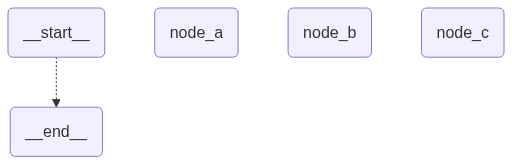

In [1]:
# 同时路由多个节点
# 不用path_map

from collections.abc import Sequence
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_qwq import ChatQwen

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatQwen(
    model="qwen3.7-max",
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的词")]).content

    return {
        "ci_poem": ci_poem
    }

def router(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    return ["node_b", "node_c"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)

builder.add_conditional_edges(
    START,
    router
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶狗", "content_type": "诗"})
joke_res = graph.invoke({"topic": "布偶狗", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)


============================== -> poem_res <- ==============================
{'topic': '布偶狗', 'content_type': '诗', 'poem': '这是一首为您创作的关于“布偶狗”的七言绝句。诗中以平水韵“十一尤”押韵，格律严谨，意在表达布偶狗虽无生命，却能长情陪伴、温暖人心的特质。\n\n**《咏布偶狗》**\n\n**娇憨布偶卧床头，**\n**静默无言解客愁。**\n**莫道无心丝絮骨，**\n**长留暖意度春秋。**\n\n**【简单赏析】**\n* **起句**（娇憨布偶卧床头）：描绘了布偶狗可爱娇憨的模样，静静地卧在床头，点明主题与陪伴的场景。\n* **承句**（静默无言解客愁）：写它虽然不会像真狗那样叫唤撒娇，但这份安静的陪伴却能化解主人心中的烦忧。\n* **转句**（莫道无心丝絮骨）：笔锋一转，点出它的本质——不要说它只是没有生命、由丝线和棉絮填充的躯壳。\n* **合句**（长留暖意度春秋）：升华情感，它用无声的守候带来长久的温暖，陪伴主人度过岁月的春秋冬夏。', 'ci_poem': '“词”可以指中国古典的宋词，也可以指现代的流行歌词。为了契合“布偶狗”这个温馨、治愈的意象，我为您创作了**三种不同风格**的词，您可以根据自己喜欢的氛围来选择：\n\n### 风格一：古典宋词风（含蓄温婉，适合静心品读）\n这首词采用经典词牌 **《鹧鸪天》**，将布偶狗化作古典意境中的静默陪伴者，写出它不吵不闹、长伴岁月的温柔。\n\n**《鹧鸪天·咏布偶狗》**\n\n绒雪裁成小犬形，明眸宛转静无声。\n不向阶前追蝶舞，偏于枕畔伴灯明。\n\n怀抱暖，梦魂轻，几番抚弄慰平生。\n虽无言语通心意，长守幽窗到五更。\n\n> **意境浅析**：上阕写布偶狗的外貌与静态，它由柔软的绒雪裁成，不会像真狗那样在阶前扑蝶，而是安静地陪在枕畔灯下；下阕写情感的羁绊，虽然它没有生命、不会说话，但每一次抚摸都能带来心灵的慰藉，长夜漫漫，它始终守着窗前的你。\n\n---\n\n### 风格二：现代流行歌词风（抒情叙事，适合谱曲弹唱）\n这首词以现代流行音乐的结构写成，讲述布偶狗作为“童年玩伴”与“成长见证者”的故事，情感细腻，适合用吉他或钢琴伴奏。\n\n**《我的布偶狗》

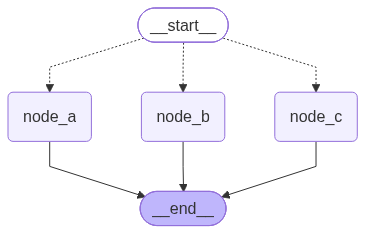

In [2]:
# 使用path_map
from collections.abc import Sequence
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langchain.messages import HumanMessage
from langchain_qwq import ChatQwen

from dotenv import load_dotenv
load_dotenv(override=True)

model = ChatQwen(
    model="qwen3.7-max",
)

class OverAllState(TypedDict):
    topic: str
    content_type: str
    poem: str
    ci_poem: str
    joke: str

def node_a(state: OverAllState) -> OverAllState:
    poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的七言绝句")]).content

    return {
        "poem": poem
    }

def node_b(state: OverAllState) -> OverAllState:
    joke = model.invoke([HumanMessage(f"写一个关于 {state['topic']} 的笑话")]).content

    return {
        "joke": joke
    }

def node_c(state: OverAllState) -> OverAllState:
    ci_poem = model.invoke([HumanMessage(f"写一首关于 {state['topic']} 的词")]).content

    return {
        "ci_poem": ci_poem
    }

def router(state: OverAllState) -> Sequence[Literal["node_a", "node_b", "node_c"]]:
    if "诗" in state["content_type"]:
        return ["node_a", "node_c"]
    return ["node_b", "node_c"]

builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_conditional_edges(
    START,
    router,
    path_map={
        "node_a": "node_a",
        "node_b": "node_b",
        "node_c": "node_c",
    }
    # path_map=["node_a", "node_b", "node_c"]
)
builder.add_edge("node_a", END)
builder.add_edge("node_b", END)
builder.add_edge("node_c", END)

graph = builder.compile()
poem_res = graph.invoke({"topic": "布偶狗", "content_type": "诗"})
joke_res = graph.invoke({"topic": "布偶狗", "content_type": "笑话"})

print('=' * 30, '-> poem_res <-', '=' * 30)
print(poem_res)
print('=' * 30, '-> joke_res <-', '=' * 30)
print(joke_res)

from IPython.display import display

display(graph)